In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from einops import reduce

import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset

In [2]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="2_02",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io")
source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [4]:
# laptop:  subset=True, num_sample_chunks=8, subsample_per_chunk=64   -> ~512 cutouts http://localhost:PORT/status
# server:  subset=False                                              -> everything
raw = cutouts_dataset.RawCutouts.download(source, subset=True, subsample_per_chunk=64,
                                          num_sample_chunks=8, n_workers=4)
print(f"{len(raw)} cutouts | {raw.images.shape} | {raw.images.nbytes / 1e9:.2f} GB")

/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 50909 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:50910' processes=4 threads=12, memory=24.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/50909/status
dropped 0 ice, 0 NaN; kept 512 / 512
512 cutouts | (512, 23, 64, 64) | 0.19 GB


2026-08-21 12:27:27,488 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='localhost:50909', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is ex

In [45]:
PATCH_SIZE = 8
SEED = 0
N_CUTOUTS = None            # cutouts used for the statistics; None = all downloaded
BLOCK = 256                 # cutouts per pass
HAS_WITHIN = PATCH_SIZE > 1  # a 1-pixel patch has no interior, so no within-patch variance

data_channels = [c for c in raw.channel_names if c not in ("XC", "YC", "SIarea")]
dataset = raw.select(data_channels)

rng = np.random.default_rng(SEED)
idx = (np.sort(rng.choice(len(dataset.X), N_CUTOUTS, replace=False))
       if N_CUTOUTS and N_CUTOUTS < len(dataset.X) else np.arange(len(dataset.X)))

Xl = dataset._log_gradients(dataset.X[idx])       # log10 on grad* channels only
N, C, H, W = Xl.shape
GRID = H // PATCH_SIZE
PPI = GRID * GRID
names = dataset.channel_names

xi, yi = dataset.coord_names.index("XC"), dataset.coord_names.index("YC")
lon = reduce(dataset.coords[idx, xi], 'n (h p1) (w p2) -> (n h w)', 'mean',
             p1=PATCH_SIZE, p2=PATCH_SIZE)
lat = reduce(dataset.coords[idx, yi], 'n (h p1) (w p2) -> (n h w)', 'mean',
             p1=PATCH_SIZE, p2=PATCH_SIZE)

print(f"{N} cutouts | {C} channels | {PPI} patches each | {N * PPI:,} patches")
print(f"resident: raw {raw.images.nbytes / 1e9:.2f} + X {dataset.X.nbytes / 1e9:.2f} "
      f"+ Xl {Xl.nbytes / 1e9:.2f} GB")
print("log10'd:", dataset.log_scaled_channels)

features ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'gradb2', 'oceTAUX', 'oceTAUY', 'gradrho2', 'turner_angle', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'relative_vorticity', 'coriolis_f', 'oceQnet', 'ekman_pumping', 'wind_stress_curl'] | coords ['XC', 'YC']
512 cutouts | 20 channels | 64 patches each | 32,768 patches
resident: raw 0.19 + X 0.17 + Xl 0.17 GB
log10'd: ['gradb2', 'gradrho2']


## 2. Per-channel variance, std and pdf

Pooled over every pixel of every patch.  Variance and std are in each channel's own
units, so they rank a channel against itself, not against the others.

In [46]:
flat = Xl.reshape(N, C, -1)
summary = pd.DataFrame({
    "variance": np.nanvar(flat, axis=(0, 2)),
    "std":      np.nanstd(flat, axis=(0, 2)),
    "mean":     np.nanmean(flat, axis=(0, 2)),
    "logged":   [n in dataset.log_scaled_channels for n in names],
}, index=names)
summary.round(5)

,variance,std,mean,logged
Eta,0.484210,0.695850,0.169070,False
Salt,1.314580,1.146550,34.628422,False
Theta,72.322639,8.504270,15.742500,False
U,0.063380,0.251750,0.039060,False
V,0.057810,0.240430,0.000640,False
W,0.000000,0.000050,0.000000,False
gradb2,0.913920,0.955990,-14.590750,True
oceTAUX,0.016050,0.126700,0.033070,False
oceTAUY,0.010060,0.100280,0.000810,False
gradrho2,0.913920,0.955990,-10.574090,True


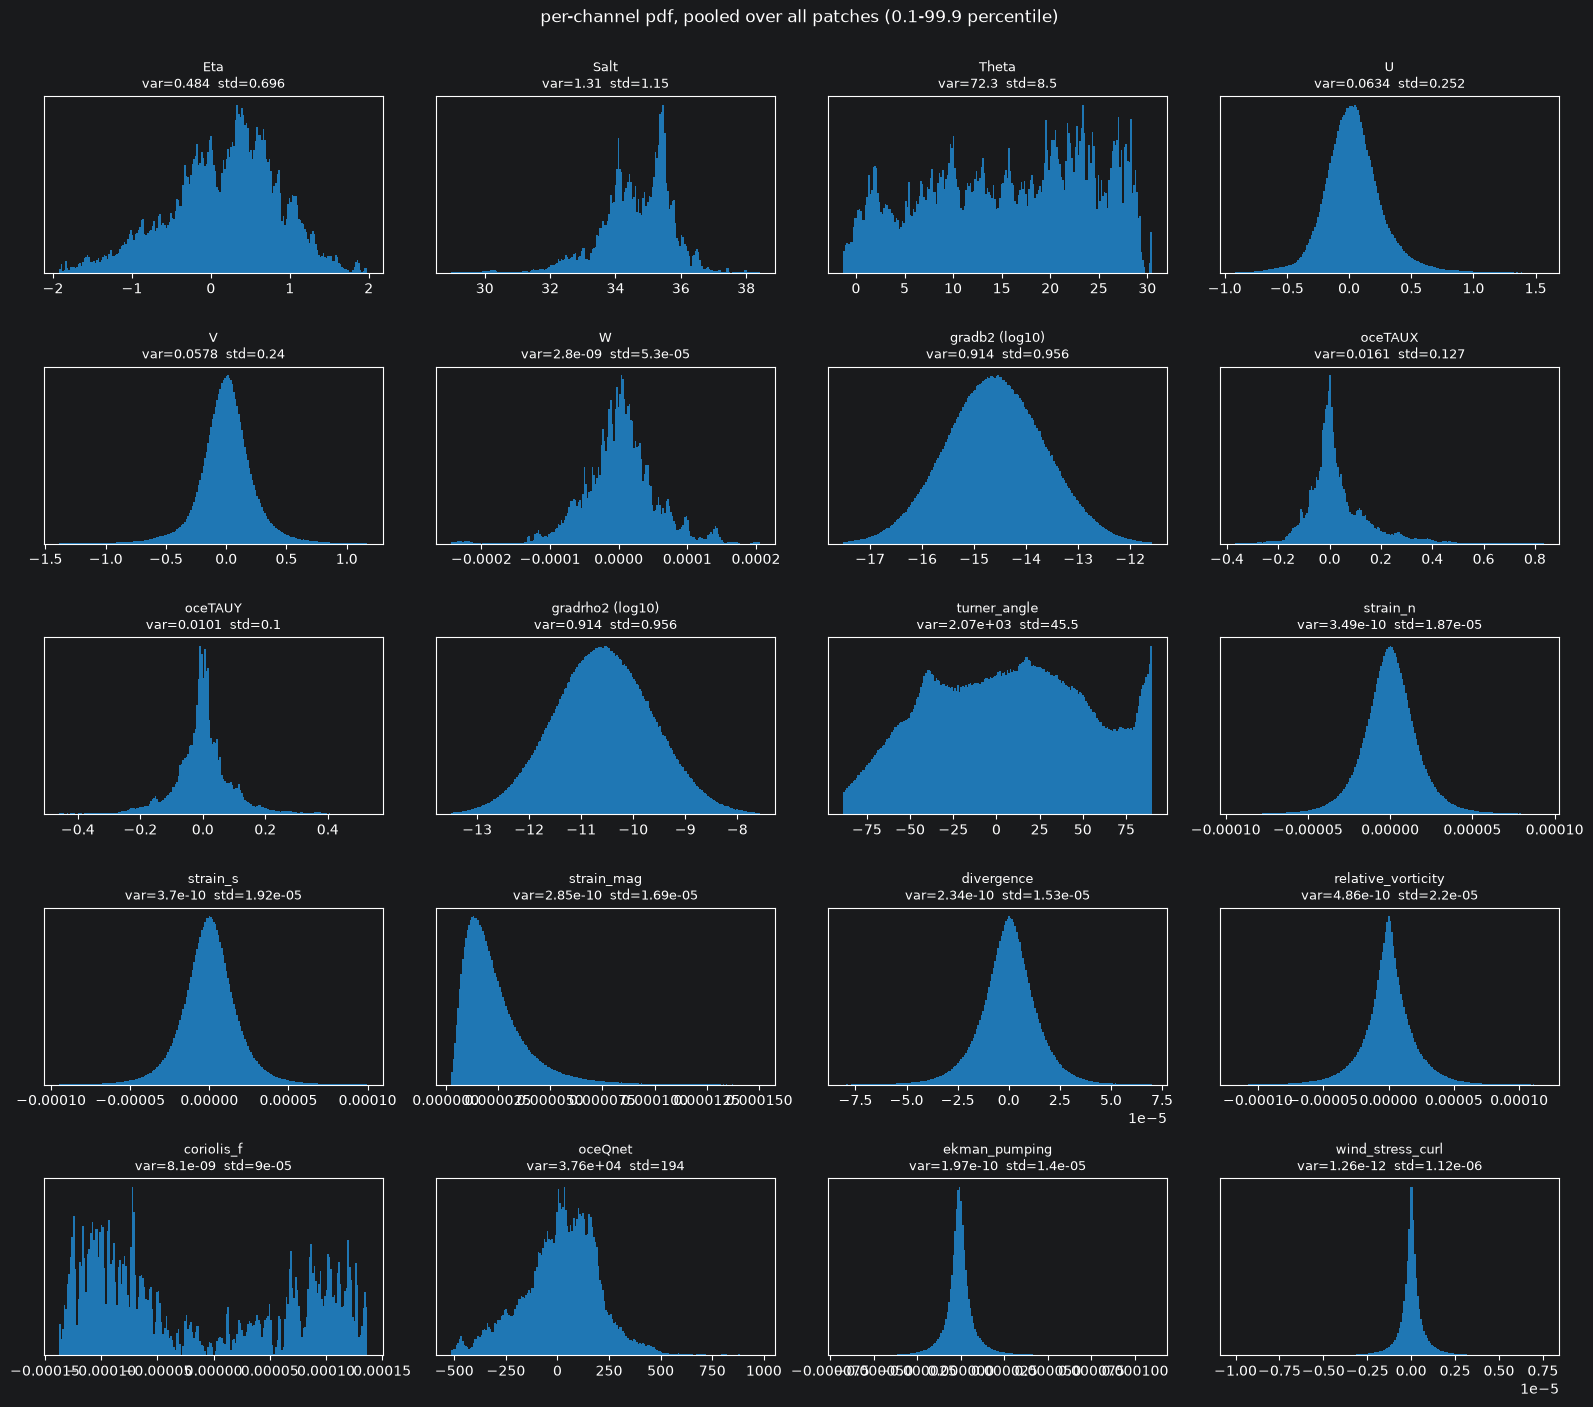

In [47]:
n_cols = 4
n_rows = -(-C // n_cols)


def panel_grid(title):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.8 * n_rows))
    fig.suptitle(title, y=1.002)
    return fig, axes.ravel()


fig, ax = panel_grid("per-channel pdf, pooled over all patches (0.1-99.9 percentile)")
for a, c in zip(ax, range(C)):
    v = flat[:, c].ravel()
    v = v[np.isfinite(v)]
    lo, hi = np.percentile(v, [0.1, 99.9])
    a.hist(v, bins=200, range=(lo, hi), density=True, color="tab:blue")
    tag = " (log10)" if names[c] in dataset.log_scaled_channels else ""
    a.set_title(f"{names[c]}{tag}\n"
                f"var={summary['variance'].iloc[c]:.3g}  std={summary['std'].iloc[c]:.3g}",
                fontsize=9)
    a.set_yticks([])
for a in ax[C:]:
    a.axis("off")
fig.tight_layout(); plt.show()

## 3. Variance across patches

The pooled variance above is one number per channel and hides how it is distributed.

**Per-patch variance** is the variance of the pixels inside each patch, one value per
patch.  A narrow distribution means every patch is equally textured; a long right
tail means a minority of patches carry the structure.

**Between vs within** splits the total: variance *of* the patch means (which patch
you are in) plus the mean of the patch variances (what the patch looks like).

In [54]:
PATCH_SIZE = 2

In [55]:
def patch_moments(X, patch_size, block):
    """Per-patch mean and variance, (N_patches, C), computed in blocks of cutouts so
    the squared field is never materialized for the whole array."""
    means, varis = [], []
    for i in range(0, len(X), block):
        b = X[i:i + block]
        m = reduce(b, 'n c (h p1) (w p2) -> (n h w) c', 'mean', p1=patch_size, p2=patch_size)
        m2 = reduce(b ** 2, 'n c (h p1) (w p2) -> (n h w) c', 'mean', p1=patch_size, p2=patch_size)
        means.append(m)
        varis.append(np.maximum(m2 - m ** 2, 0.0))
    return np.concatenate(means), np.concatenate(varis)


patch_mean, patch_var = patch_moments(Xl, PATCH_SIZE, BLOCK)
print("per-patch mean / variance", patch_mean.shape)

per-patch mean / variance (524288, 20)


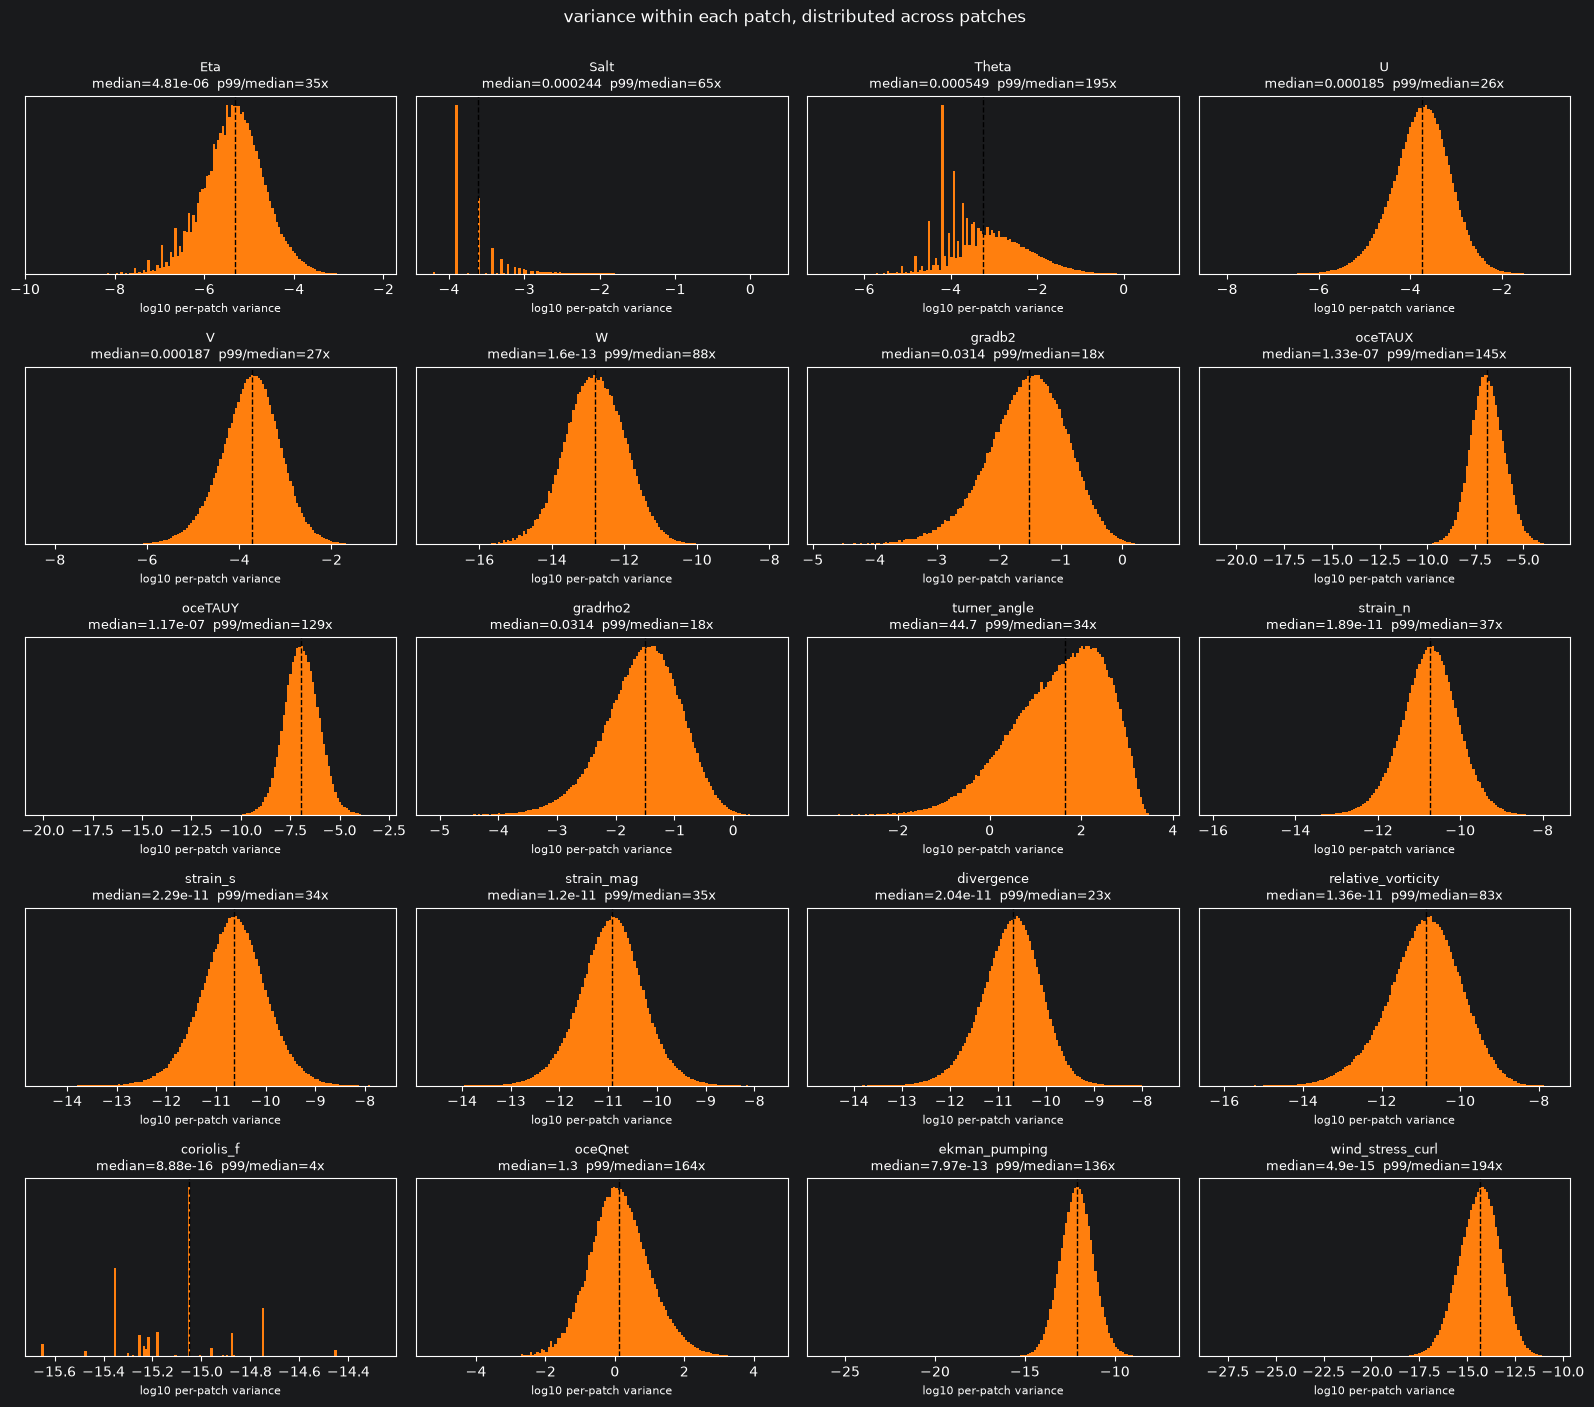

In [56]:
if not HAS_WITHIN:
    print("patch_size=1: a patch is a single pixel, so within-patch variance is "
          "identically 0.  This panel and sections 4 and 6 are undefined; the "
          "between-patch split in section 3 and the budget still hold.")
fig, ax = panel_grid("variance within each patch, distributed across patches")
for a, c in zip(ax, range(C) if HAS_WITHIN else []):
    v = patch_var[:, c]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        a.set_title(f"{names[c]}\n(no positive within-patch variance)", fontsize=9)
        a.axis("off")
        continue
    a.hist(np.log10(v), bins=150, color="tab:orange")
    med, p99 = np.median(v), np.percentile(v, 99)
    a.axvline(np.log10(med), color="k", ls="--", lw=1)
    a.set_title(f"{names[c]}\nmedian={med:.3g}  p99/median={p99 / med:.0f}x", fontsize=9)
    a.set_xlabel("log10 per-patch variance", fontsize=8)
    a.set_yticks([])
for a in ax[C if HAS_WITHIN else 0:]:
    a.axis("off")
fig.tight_layout(); plt.show()

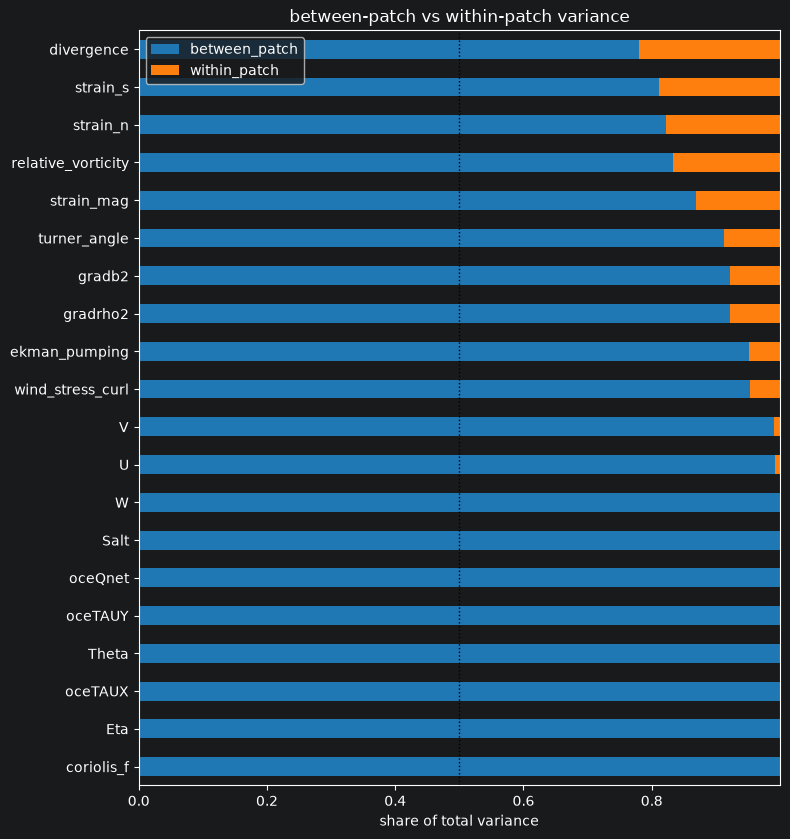

,between_patch,within_patch
coriolis_f,1.000,0.000
Eta,1.000,0.000
oceTAUX,1.000,0.000
Theta,1.000,0.000
oceTAUY,1.000,0.000
oceQnet,1.000,0.000
Salt,1.000,0.000
W,0.999,0.001
U,0.992,0.008
V,0.991,0.009


In [51]:
between = np.nanvar(patch_mean, axis=0)
within = np.nanmean(patch_var, axis=0)
share = pd.DataFrame({"between_patch": between / (between + within),
                      "within_patch": within / (between + within)}, index=names)
share = share.sort_values("within_patch")

share.plot.barh(stacked=True, figsize=(8, 0.35 * C + 1.5), color=["tab:blue", "tab:orange"])
plt.axvline(0.5, color="k", lw=1, ls=":"); plt.xlabel("share of total variance")
plt.title("between-patch vs within-patch variance"); plt.tight_layout(); plt.show()
share.round(3)

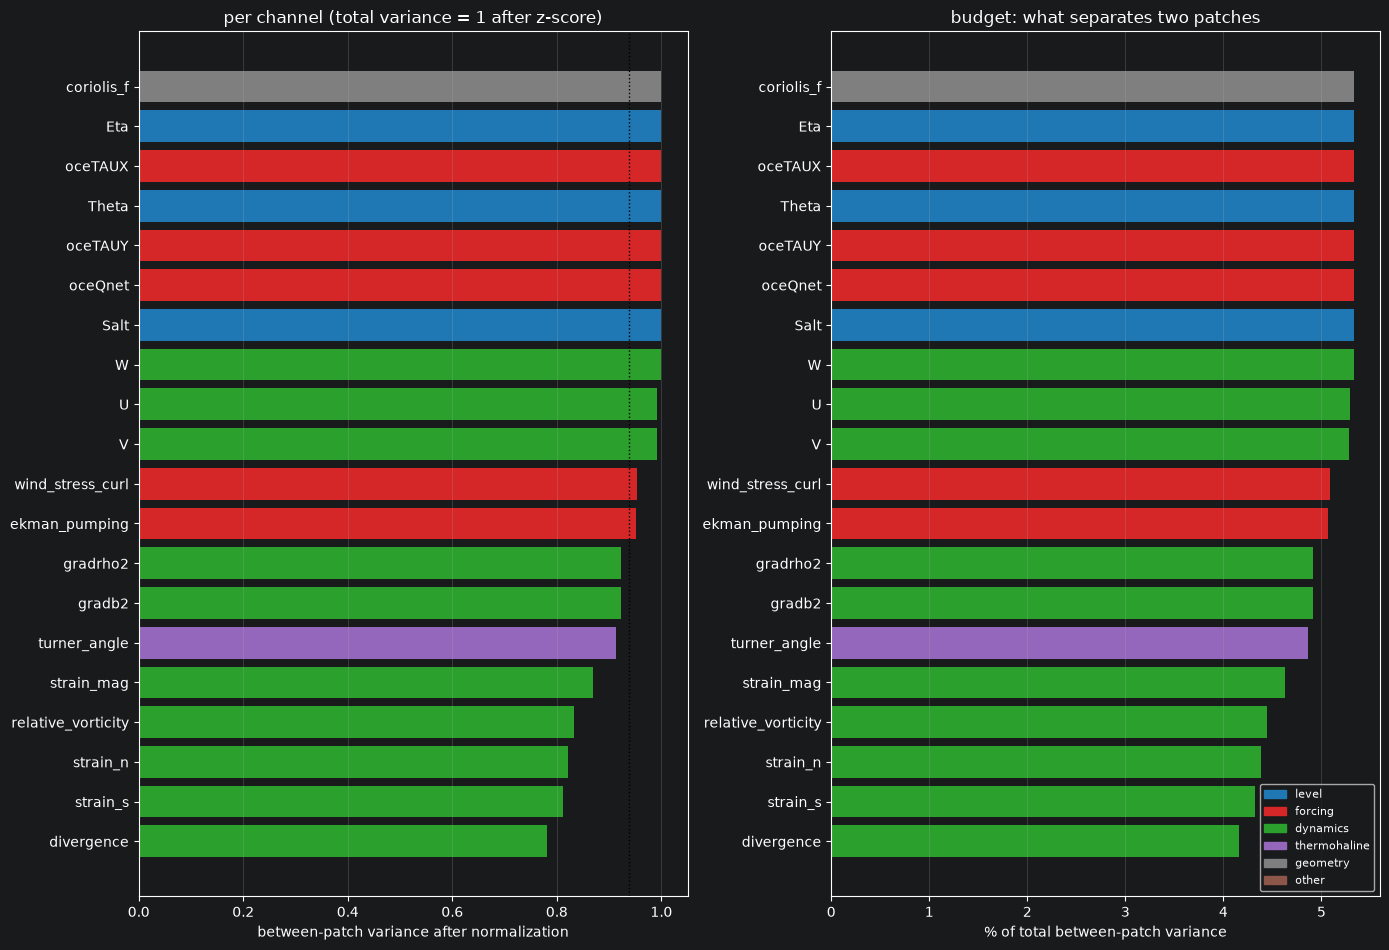

share of the between-patch variance budget by group (%):
dynamics        47.700001
forcing         26.100000
level           16.000000
geometry         5.300000
thermohaline     4.900000


In [52]:
# After z-scoring, every channel has total variance 1, so a channel's between-patch
# SHARE is its post-normalization between-patch variance.  The budget turns those into
# each channel's cut of everything that separates one patch from another.
GROUPS = {"level": ["Eta", "Salt", "Theta"],
          "forcing": ["oceTAUX", "oceTAUY", "oceQnet", "ekman_pumping", "wind_stress_curl"],
          "dynamics": ["U", "V", "W", "gradb2", "gradrho2", "strain_n", "strain_s",
                       "strain_mag", "divergence", "relative_vorticity"],
          "thermohaline": ["turner_angle"], "geometry": ["coriolis_f"]}
COLOR = {"level": "tab:blue", "forcing": "tab:red", "dynamics": "tab:green",
         "thermohaline": "tab:purple", "geometry": "tab:gray", "other": "tab:brown"}
group_of = {c: g for g, cs in GROUPS.items() for c in cs}

total = np.where(between + within > 0, between + within, np.nan)
between_norm = pd.Series(between / total, index=names)
budget = between_norm / between_norm.sum()
grp = pd.Series([group_of.get(n, "other") for n in names], index=names)

fig, axes = plt.subplots(1, 2, figsize=(14, 0.38 * C + 2))
for ax, series, xlab, title in (
        (axes[0], between_norm, "between-patch variance after normalization",
         "per channel (total variance = 1 after z-score)"),
        (axes[1], 100 * budget, "% of total between-patch variance",
         "budget: what separates two patches")):
    s = series.sort_values()
    ax.barh(s.index, s.values, color=[COLOR[group_of.get(n, "other")] for n in s.index])
    ax.set_xlabel(xlab); ax.set_title(title); ax.grid(alpha=0.3, axis="x")
axes[0].axvline(between_norm.mean(), color="k", ls=":", lw=1)
axes[1].legend([plt.Rectangle((0, 0), 1, 1, color=COLOR[g]) for g in COLOR],
               list(COLOR), fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

print("share of the between-patch variance budget by group (%):")
print((100 * budget.groupby(grp).sum().sort_values(ascending=False)).round(1).to_string())

## Does the split move with patch size?

The within/between split is a property of the patch size as much as of the field.
Shrinking the patch moves variance from within to between, where a distance metric
can see it.  `patch_size=1` is pinned at zero within-patch share by definition and
anchors the left end of every curve.

Where a channel's curve starts to climb is its characteristic spatial scale.

patch_size  1 |    2,097,152 patches | mean within-share 0.000
patch_size  2 |      524,288 patches | mean within-share 0.062
patch_size  4 |      131,072 patches | mean within-share 0.163
patch_size  8 |       32,768 patches | mean within-share 0.259


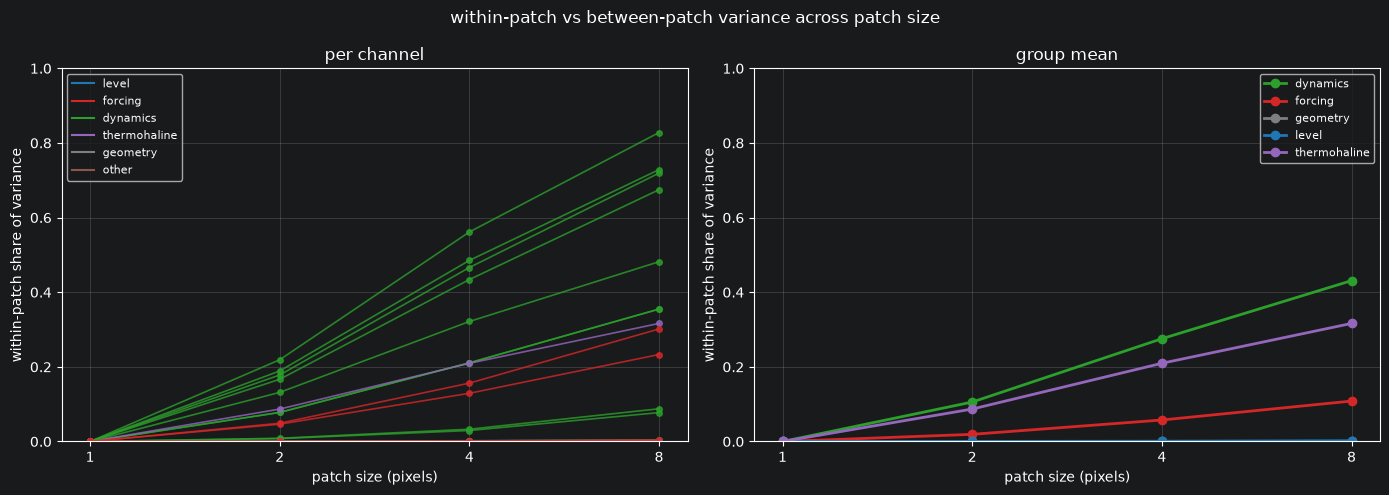

,1,2,4,8
Eta,0.0,0.000,0.000,0.001
Salt,0.0,0.000,0.002,0.005
Theta,0.0,0.000,0.000,0.001
U,0.0,0.008,0.029,0.077
V,0.0,0.009,0.033,0.088
W,0.0,0.001,0.002,0.003
gradb2,0.0,0.078,0.211,0.355
oceTAUX,0.0,0.000,0.000,0.001
oceTAUY,0.0,0.000,0.000,0.002
gradrho2,0.0,0.078,0.211,0.355


In [53]:
def split_at(X, patch_size, block):
    """Between/within variance per channel at one patch size, accumulated so the
    per-patch arrays are never held -- ps=1 on a full run is 120M patches."""
    n = 0
    s1 = s2 = wsum = 0.0
    for i in range(0, len(X), block):
        b = X[i:i + block]
        m = reduce(b, 'n c (h p1) (w p2) -> (n h w) c', 'mean', p1=patch_size, p2=patch_size)
        m2 = reduce(b ** 2, 'n c (h p1) (w p2) -> (n h w) c', 'mean', p1=patch_size, p2=patch_size)
        v = np.maximum(m2 - m ** 2, 0.0)
        n += len(m)
        s1 = s1 + m.sum(0, dtype=np.float64)
        s2 = s2 + (m.astype(np.float64) ** 2).sum(0)
        wsum = wsum + v.sum(0, dtype=np.float64)
    return s2 / n - (s1 / n) ** 2, wsum / n, n


PS_SWEEP = [1, 2, 4, 8]
assert all(H % ps == 0 and W % ps == 0 for ps in PS_SWEEP)

cols = {}
for ps in PS_SWEEP:
    b, w, n = split_at(Xl, ps, BLOCK)
    t = b + w
    cols[ps] = np.where(t > 0, w / np.where(t > 0, t, 1.0), np.nan)
    print(f"patch_size {ps:>2} | {n:>12,} patches | mean within-share {np.nanmean(cols[ps]):.3f}")

within_share = pd.DataFrame(cols, index=names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for nme in names:
    axes[0].plot(PS_SWEEP, within_share.loc[nme], marker="o", ms=4, lw=1.2, alpha=0.8,
                 color=COLOR[group_of.get(nme, "other")])
axes[0].legend([plt.Line2D([], [], color=COLOR[g]) for g in COLOR], list(COLOR), fontsize=8)
axes[0].set_title("per channel")

for g, row in within_share.groupby(grp).mean().iterrows():
    axes[1].plot(PS_SWEEP, row.values, marker="o", lw=2, color=COLOR.get(g, "k"), label=g)
axes[1].legend(fontsize=8)
axes[1].set_title("group mean")

for a in axes:
    a.set_xscale("log", base=2); a.set_xticks(PS_SWEEP); a.set_xticklabels(PS_SWEEP)
    a.set_xlabel("patch size (pixels)"); a.set_ylabel("within-patch share of variance")
    a.set_ylim(0, 1); a.grid(alpha=0.3)
fig.suptitle("within-patch vs between-patch variance across patch size")
fig.tight_layout(); plt.show()

within_share.round(3)

## 4. How concentrated is the variance?

Lorenz curve per channel: patches sorted by variance, descending, against the share
of total variance they hold.  A curve hugging the top-left means a small minority of
patches carry nearly all of it.  Gini is that curve as one number -- 0 is every patch
equally textured, 1 is all the texture in one patch.

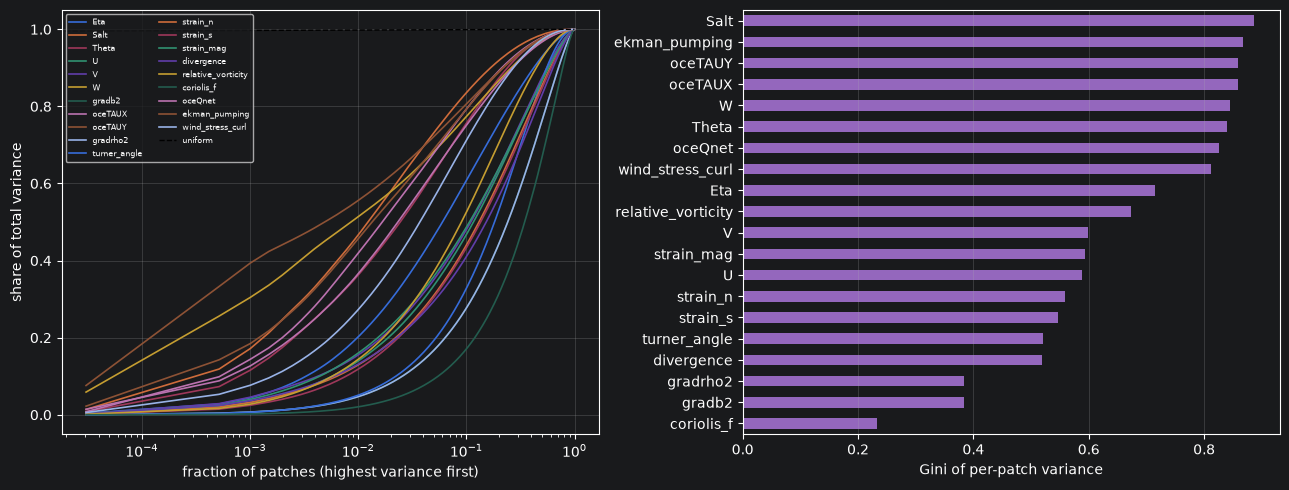

share of total variance held by the top 10% of patches:
Salt                  0.835
ekman_pumping         0.806
oceTAUY               0.793
oceTAUX               0.793
W                     0.774
Theta                 0.756
oceQnet               0.751
wind_stress_curl      0.712
Eta                   0.608
relative_vorticity    0.525
strain_mag            0.486
V                     0.480
U                     0.467
strain_n              0.440
strain_s              0.433
divergence            0.410
turner_angle          0.328
gradrho2              0.277
gradb2                0.277
coriolis_f            0.171


In [19]:
def lorenz(v):
    v = np.sort(v[np.isfinite(v)])                       # ascending
    n = len(v)
    if n == 0 or v.sum() == 0:
        return np.array([]), np.array([]), np.nan
    i = np.arange(1, n + 1)
    gini = float(2.0 * (i * v).sum() / (n * v.sum()) - (n + 1.0) / n)
    desc = v[::-1]
    return i / n, np.cumsum(desc) / desc.sum(), gini


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ginis = {}
for c in (range(C) if HAS_WITHIN else []):
    frac, cum, g = lorenz(patch_var[:, c])
    ginis[names[c]] = g
    step = max(1, len(frac) // 2000)
    axes[0].plot(frac[::step], cum[::step], lw=1.2, label=names[c])
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="uniform")
axes[0].set_xscale("log"); axes[0].set_xlabel("fraction of patches (highest variance first)")
axes[0].set_ylabel("share of total variance"); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=6, ncol=2)

g = pd.Series(ginis).sort_values()
g.plot.barh(ax=axes[1], color="tab:purple")
axes[1].set_xlabel("Gini of per-patch variance"); axes[1].grid(alpha=0.3, axis="x")
fig.tight_layout(); plt.show()

if HAS_WITHIN:
    tot = np.nansum(patch_var, axis=0)
    top = np.sort(patch_var, axis=0)[::-1][:max(1, len(patch_var) // 10)].sum(axis=0)
    top10 = pd.Series(np.where(tot > 0, top / np.where(tot > 0, tot, 1.0), np.nan), index=names)
    print("share of total variance held by the top 10% of patches:")
    print(top10.sort_values(ascending=False).round(3).to_string())
else:
    print("patch_size=1: no within-patch variance to concentrate.")

## 5. Where is the variance?

Per-patch variance binned on a lon/lat grid.  If a channel's texture is concentrated
in the western boundary currents, any structure built on it is partly a map.

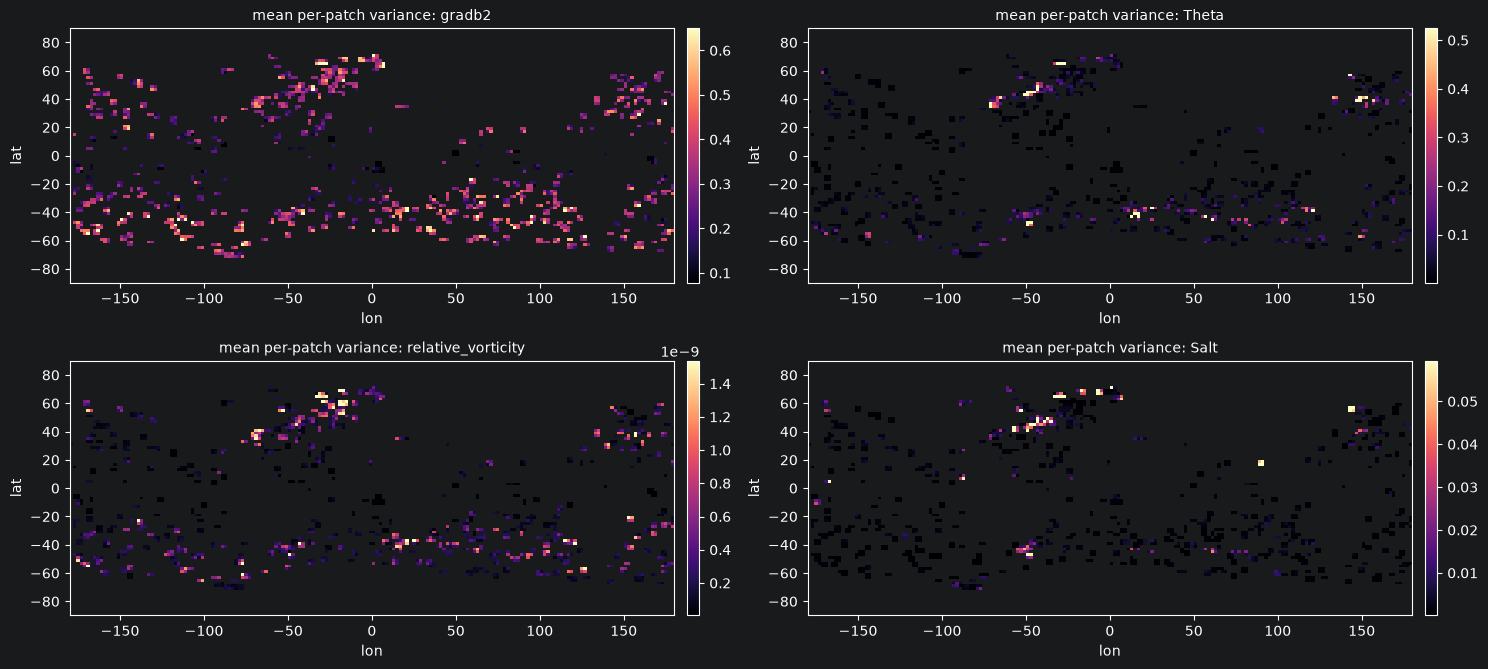

In [23]:
MAP_CHANNELS = [c for c in ["gradb2", "Theta", "relative_vorticity", "Salt"] if c in names]
BINS = (180, 90)

lon_e = np.linspace(-180, 180, BINS[0] + 1)
lat_e = np.linspace(-90, 90, BINS[1] + 1)
count, _, _ = np.histogram2d(lon, lat, bins=[lon_e, lat_e])

fig, axes = plt.subplots(-(-len(MAP_CHANNELS) // 2), 2,
                         figsize=(15, 3.4 * -(-len(MAP_CHANNELS) // 2)), squeeze=False)
for a, name in zip(axes.ravel(), MAP_CHANNELS):
    v = patch_var[:, names.index(name)]
    tot, _, _ = np.histogram2d(lon, lat, bins=[lon_e, lat_e], weights=np.nan_to_num(v))
    grid = np.where(count > 0, tot / np.maximum(count, 1), np.nan)
    finite = grid[np.isfinite(grid)]
    im = a.pcolormesh(lon_e, lat_e, grid.T, cmap="magma",
                      vmin=np.percentile(finite, 2), vmax=np.percentile(finite, 98))
    a.set_title(f"mean per-patch variance: {name}", fontsize=10)
    a.set_xlabel("lon"); a.set_ylabel("lat")
    fig.colorbar(im, ax=a, fraction=0.025, pad=0.02)
for a in axes.ravel()[len(MAP_CHANNELS):]:
    a.axis("off")
fig.tight_layout(); plt.show()

## 6. Does texture track latitude?

Cutouts are a fixed 150 km resampled to a fixed 64x64, so the number of native cells
averaged into each pixel varies with latitude.  A latitude trend in within-patch
variance is partly grid resolution rather than ocean.

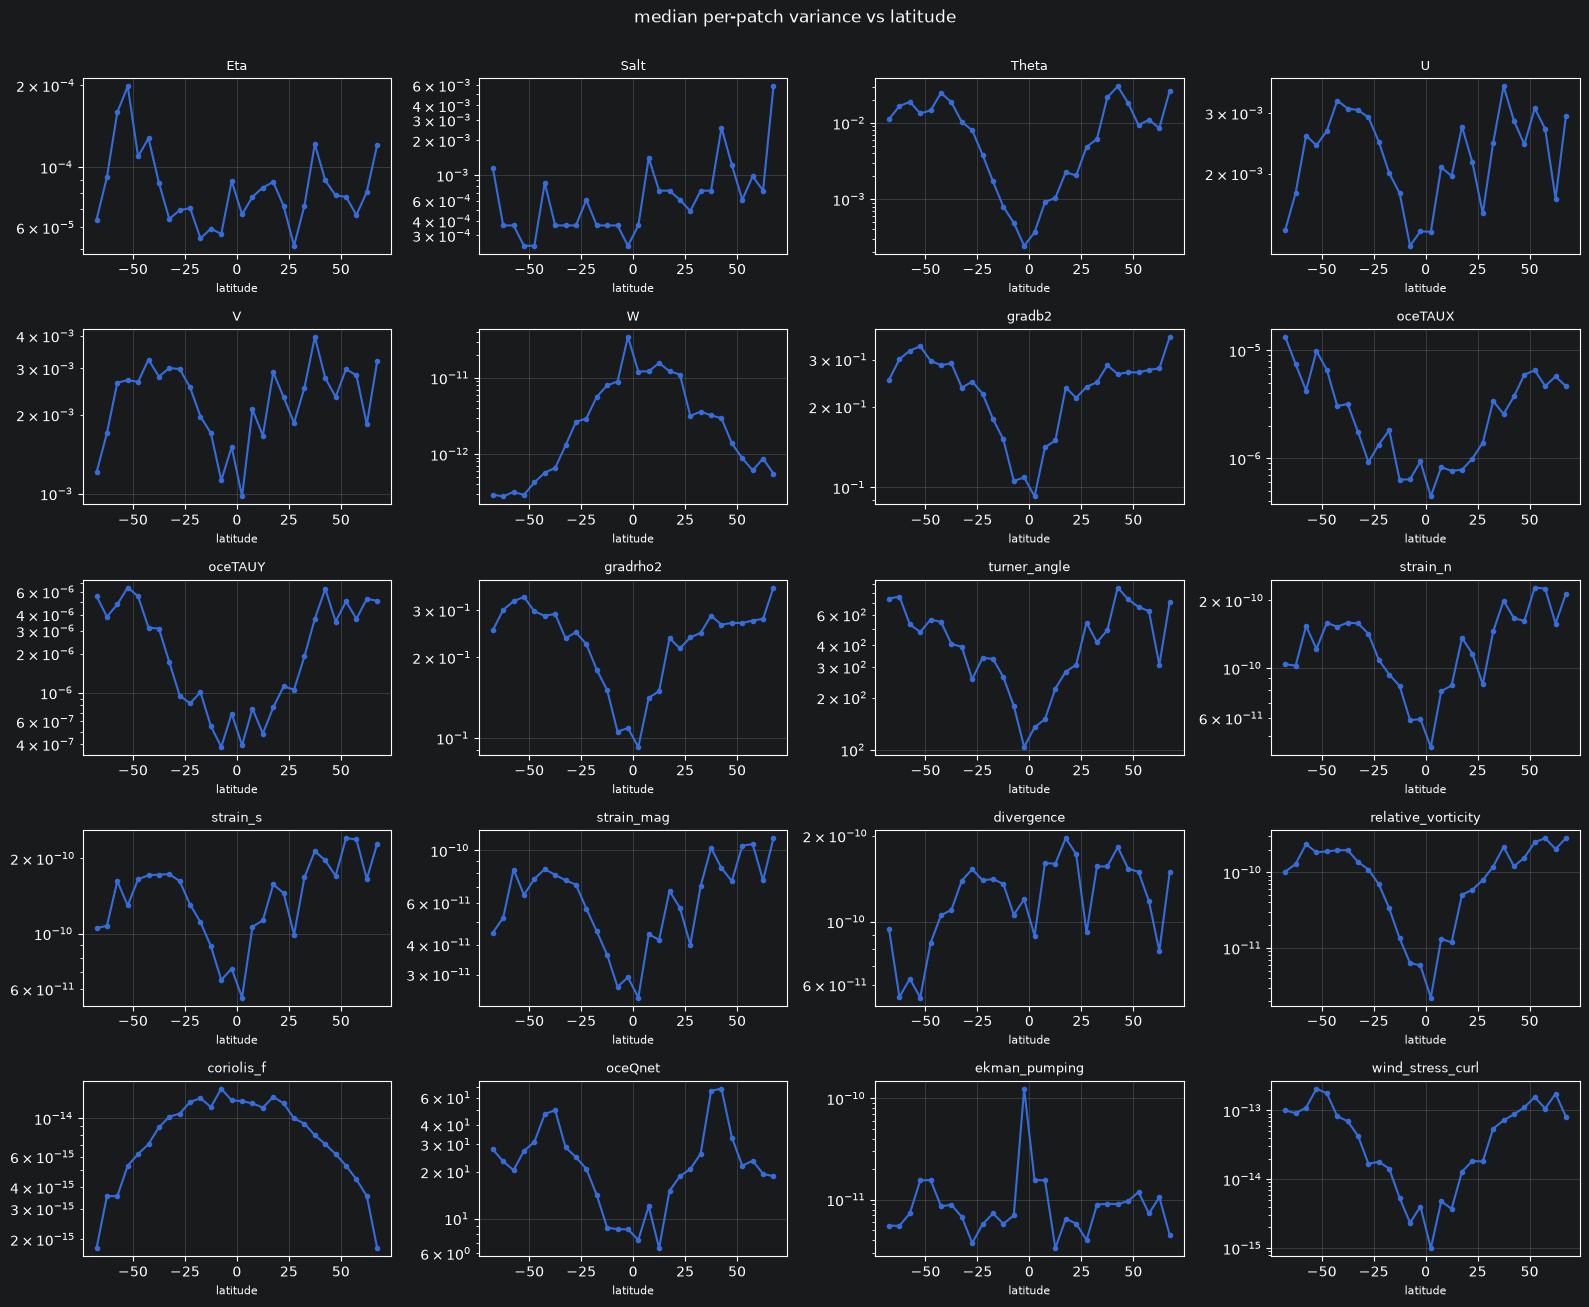

In [21]:
edges = np.arange(-70, 75, 5)
centre = edges[:-1] + 2.5
which = np.digitize(lat, edges) - 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.6 * n_rows))
for a, c in zip(axes.ravel(), range(C) if HAS_WITHIN else []):
    med = np.array([np.nanmedian(patch_var[which == b, c]) if (which == b).sum() > 50 else np.nan
                    for b in range(len(centre))])
    a.plot(centre, med, marker="o", ms=3)
    a.set_title(names[c], fontsize=9); a.set_xlabel("latitude", fontsize=8)
    a.grid(alpha=0.3)
    if np.any(np.isfinite(med) & (med > 0)):
        a.set_yscale("log")
for a in axes.ravel()[C if HAS_WITHIN else 0:]:
    a.axis("off")
fig.suptitle("median per-patch variance vs latitude", y=1.002)
fig.tight_layout(); plt.show()

## 7. Three-way split

The between-patch term in section 3 mixes two different things: a patch differing
from its neighbours in the same scene, and one scene differing from another.  The
first is local structure, the second is geography.

- **within_patch** -- pixels inside a patch
- **between_patch_in_cutout** -- patches against their own cutout's mean
- **between_cutout** -- cutout means against the global mean

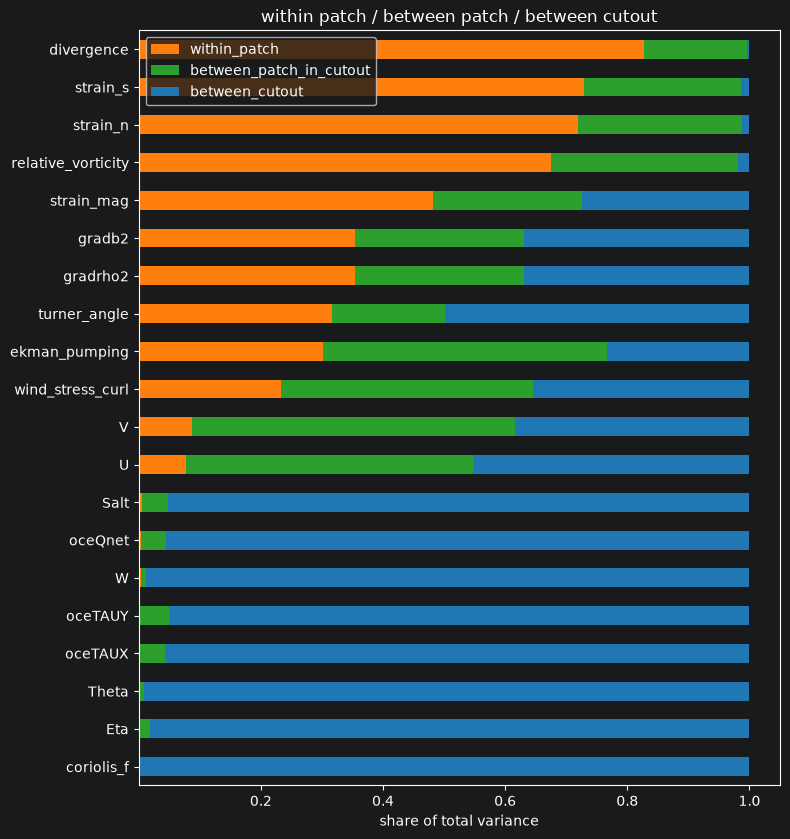

,within_patch,between_patch_in_cutout,between_cutout
coriolis_f,0.000,0.000,1.000
Eta,0.001,0.017,0.982
Theta,0.001,0.007,0.992
oceTAUX,0.001,0.042,0.957
oceTAUY,0.002,0.048,0.950
W,0.003,0.008,0.988
oceQnet,0.004,0.040,0.956
Salt,0.005,0.043,0.952
U,0.077,0.469,0.453
V,0.088,0.528,0.384


In [22]:
pm = patch_mean.reshape(N, PPI, C)
cutout_mean = pm.mean(axis=1)                                    # (N, C)

three = pd.DataFrame({
    "within_patch":            np.nanmean(patch_var, axis=0),
    "between_patch_in_cutout": np.nanmean((pm - cutout_mean[:, None, :]) ** 2, axis=(0, 1)),
    "between_cutout":          np.nanvar(cutout_mean, axis=0),
}, index=names)
three = three.div(three.sum(axis=1).replace(0, np.nan), axis=0).sort_values("within_patch")

three.plot.barh(stacked=True, figsize=(8, 0.35 * C + 1.5),
                color=["tab:orange", "tab:green", "tab:blue"])
plt.xlabel("share of total variance"); plt.title("within patch / between patch / between cutout")
plt.tight_layout(); plt.show()
three.round(3)

## Structure or noise?

The within/between split says how much variance sits inside a patch, not whether that
variance is anything.  Spatial autocorrelation separates the two.

- **decorrelation <~ 1 pixel** -- the channel is white at pixel scale.  Its within-patch
  variance adds a roughly constant amount to every pairwise distance without
  discriminating between pairs, so shrinking the patch discards nothing.
- **decorrelation >~ patch size** -- the within-patch variance is real spatial structure,
  and a smaller patch throws away morphology.

The FFT autocorrelation is circular, so it treats each cutout as periodic and
underestimates long correlation lengths; a planar ramp reads as ~12 px rather than the
domain scale.  Short lags -- the regime that separates noise from structure -- are
reliable.

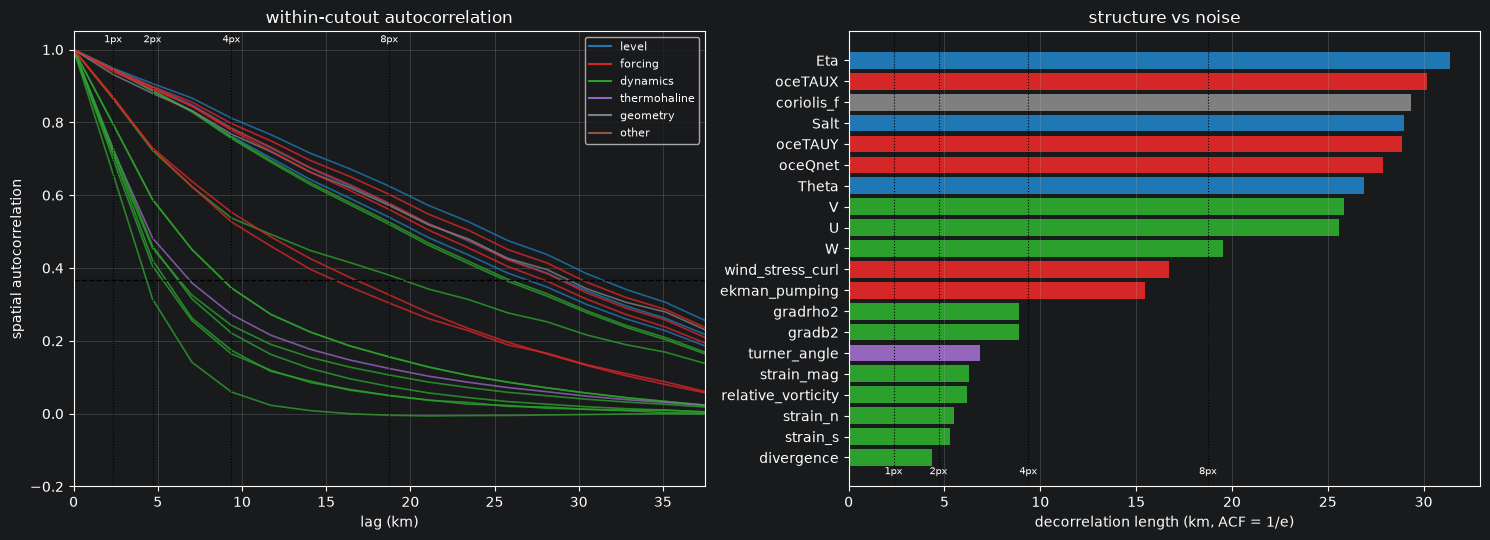

                    lag 1px  lag 2px  lag 4px  lag 8px  decorr_km  decorr_px
divergence            0.659    0.315    0.060   -0.004      4.326      1.846
strain_s              0.699    0.405    0.164    0.050      5.275      2.251
strain_n              0.715    0.422    0.174    0.050      5.478      2.337
relative_vorticity    0.729    0.460    0.221    0.075      6.183      2.638
strain_mag            0.714    0.454    0.242    0.106      6.259      2.670
turner_angle          0.725    0.482    0.272    0.124      6.860      2.927
gradb2                0.796    0.588    0.345    0.156      8.871      3.785
gradrho2              0.796    0.588    0.345    0.156      8.871      3.785
ekman_pumping         0.870    0.727    0.527    0.304     15.454      6.594
wind_stress_curl      0.866    0.729    0.553    0.326     16.716      7.132
W                     0.865    0.723    0.537    0.380     19.516      8.327
U                     0.946    0.887    0.756    0.520     25.574     10.912

In [57]:
KM_PER_PIXEL = 150 / 64        # target_km_res / down_sample_res from the cutout config


def radial_acf(X, block=BLOCK):
    """Radially averaged spatial autocorrelation per channel, from the 2-D FFT of each
    cutout's anomaly.  Returns (C, H//2): correlation against integer pixel lag."""
    n, C, Hh, Ww = X.shape
    acc = np.zeros((C, Hh, Ww))
    for i in range(0, n, block):
        b = np.asarray(X[i:i + block], dtype="float32")
        b = b - b.mean(axis=(2, 3), keepdims=True)
        F = np.fft.rfft2(b, axes=(2, 3))
        acc += np.fft.irfft2(F.real ** 2 + F.imag ** 2, s=(Hh, Ww), axes=(2, 3)).sum(0)
    ac = np.fft.fftshift(acc, axes=(1, 2))
    ac = ac / ac[:, Hh // 2, Ww // 2][:, None, None]
    yy, xx = np.mgrid[0:Hh, 0:Ww]
    rb = np.hypot(yy - Hh // 2, xx - Ww // 2).round().astype(int)
    nb = Hh // 2
    cnt = np.bincount(rb.ravel(), minlength=rb.max() + 1)[:nb]
    return np.stack([np.bincount(rb.ravel(), ac[c].ravel(), rb.max() + 1)[:nb] / np.maximum(cnt, 1)
                     for c in range(C)])


def decorr_px(prof, thresh=1 / np.e):
    """Lag at which each profile first crosses thresh, linearly interpolated."""
    out = []
    for p in prof:
        below = np.where(p < thresh)[0]
        if below.size == 0 or below[0] == 0:
            out.append(0.0 if below.size else np.nan)
            continue
        k = below[0]
        out.append(k - 1 + (p[k - 1] - thresh) / (p[k - 1] - p[k] + 1e-30))
    return np.array(out)


acf = radial_acf(Xl)
lag_km = np.arange(acf.shape[1]) * KM_PER_PIXEL
dec_km = pd.Series(decorr_px(acf) * KM_PER_PIXEL, index=names)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for c, nme in enumerate(names):
    axes[0].plot(lag_km, acf[c], color=COLOR[group_of.get(nme, "other")], lw=1.2, alpha=0.8)
axes[0].axhline(1 / np.e, color="k", ls="--", lw=1)
for ps in PS_SWEEP:
    axes[0].axvline(ps * KM_PER_PIXEL, color="k", ls=":", lw=0.8)
    axes[0].text(ps * KM_PER_PIXEL, 1.02, f"{ps}px", ha="center", fontsize=7)
axes[0].set_xlim(0, 2 * PS_SWEEP[-1] * KM_PER_PIXEL); axes[0].set_ylim(-0.2, 1.05)
axes[0].set_xlabel("lag (km)"); axes[0].set_ylabel("spatial autocorrelation")
axes[0].set_title("within-cutout autocorrelation"); axes[0].grid(alpha=0.3)
axes[0].legend([plt.Line2D([], [], color=COLOR[g]) for g in COLOR], list(COLOR), fontsize=8)

d = dec_km.sort_values()
axes[1].barh(d.index, d.values, color=[COLOR[group_of.get(n, "other")] for n in d.index])
for ps in PS_SWEEP:
    axes[1].axvline(ps * KM_PER_PIXEL, color="k", ls=":", lw=0.8)
    axes[1].text(ps * KM_PER_PIXEL, -0.8, f"{ps}px", ha="center", fontsize=7)
axes[1].set_xlabel("decorrelation length (km, ACF = 1/e)")
axes[1].set_title("structure vs noise"); axes[1].grid(alpha=0.3, axis="x")
fig.tight_layout(); plt.show()

table = pd.DataFrame({f"lag {l}px": acf[:, l] for l in PS_SWEEP}, index=names)
table["decorr_km"] = dec_km
table["decorr_px"] = dec_km / KM_PER_PIXEL
print(table.sort_values("decorr_px").round(3).to_string())

## Physical patch features

Eleven per-patch quantities, replacing the raw pixel vector.  Because every feature
contributes equally to distance after normalization, the count of each kind is the
weighting -- so `Theta` is one feature rather than 64 pixels.

- **state** -- Theta mean, Salt mean
- **dynamical regime** -- Ro = zeta/f, S/f, div/f, each as a patch mean and std
- **frontal sharpness** -- log10 gradb2 mean, max and std within the patch

The kinematic terms are divided by f because they share its units: without that a
value partly encodes latitude, since f varies by an order of magnitude from the
tropics to 60 degrees.  Ro divides by signed f so cyclonic is positive in both
hemispheres; S/f and div/f divide by |f| so strain stays positive and convergence
stays convergence south of the equator.

In [58]:
OMEGA = 7.2921e-5
F_FLOOR = 2 * OMEGA * np.sin(np.deg2rad(5.0))      # |f| at 5 deg; the /f ratios blow up inside this
FEATURE_CHANNELS = ["Theta", "Salt", "gradb2", "relative_vorticity",
                    "strain_mag", "divergence", "coriolis_f"]


def _patch_stats(field, p, want):
    """mean / std / max per patch for one (n, H, W) field, in get_patches order."""
    out = {"mean": reduce(field, 'n (h p1) (w p2) -> (n h w)', 'mean', p1=p, p2=p)}
    if "std" in want:
        m2 = reduce(field ** 2, 'n (h p1) (w p2) -> (n h w)', 'mean', p1=p, p2=p)
        out["std"] = np.sqrt(np.maximum(m2 - out["mean"] ** 2, 0.0))
    if "max" in want:
        out["max"] = reduce(field, 'n (h p1) (w p2) -> (n h w)', 'max', p1=p, p2=p)
    return out


def build_patch_features(dataset, patch_size, block=256):
    """Per-patch physical features, aligned with get_patches order.

    Returns (features, near_equator) -- near_equator flags patches touching
    |lat| < 5 deg, where the /f ratios are unusable.
    """
    missing = [c for c in FEATURE_CHANNELS if c not in dataset.channel_names]
    if missing:
        raise ValueError(f"channels not selected: {missing}")
    ix = {c: dataset.channel_names.index(c) for c in FEATURE_CHANNELS}
    X = dataset.X

    sample = X[::max(1, len(X) // 64), ix["gradb2"]]
    pos = sample[sample > 0]
    gfloor = float(pos.min()) if pos.size else 1e-20      # mirrors the loader's _safe_log10

    acc, eq = {}, []
    for i in range(0, len(X), block):
        b = np.asarray(X[i:i + block], dtype="float32")
        f = b[:, ix["coriolis_f"]]
        sign = np.where(f < 0, -1.0, 1.0)
        f_signed = sign * np.maximum(np.abs(f), F_FLOOR)
        eq.append(_patch_stats((np.abs(f) < F_FLOOR).astype("float32"),
                               patch_size, ())["mean"] > 0)

        lg = np.log10(np.maximum(b[:, ix["gradb2"]], gfloor))
        part = {"Theta_mean": _patch_stats(b[:, ix["Theta"]], patch_size, ())["mean"],
                "Salt_mean":  _patch_stats(b[:, ix["Salt"]],  patch_size, ())["mean"]}
        for name, fld in (("Ro",    b[:, ix["relative_vorticity"]] / f_signed),
                          ("S_f",   b[:, ix["strain_mag"]] / np.abs(f_signed)),
                          ("div_f", b[:, ix["divergence"]] / np.abs(f_signed))):
            s = _patch_stats(fld, patch_size, ("std",))
            part[f"{name}_mean"], part[f"{name}_std"] = s["mean"], s["std"]
        s = _patch_stats(lg, patch_size, ("std", "max"))
        part["loggradb2_mean"], part["loggradb2_std"], part["loggradb2_max"] = \
            s["mean"], s["std"], s["max"]

        for k, v in part.items():
            acc.setdefault(k, []).append(v)

    order = ["Theta_mean", "Salt_mean", "Ro_mean", "Ro_std", "S_f_mean", "S_f_std",
             "div_f_mean", "div_f_std", "loggradb2_mean", "loggradb2_max", "loggradb2_std"]
    return pd.DataFrame({k: np.concatenate(acc[k]) for k in order}), np.concatenate(eq)

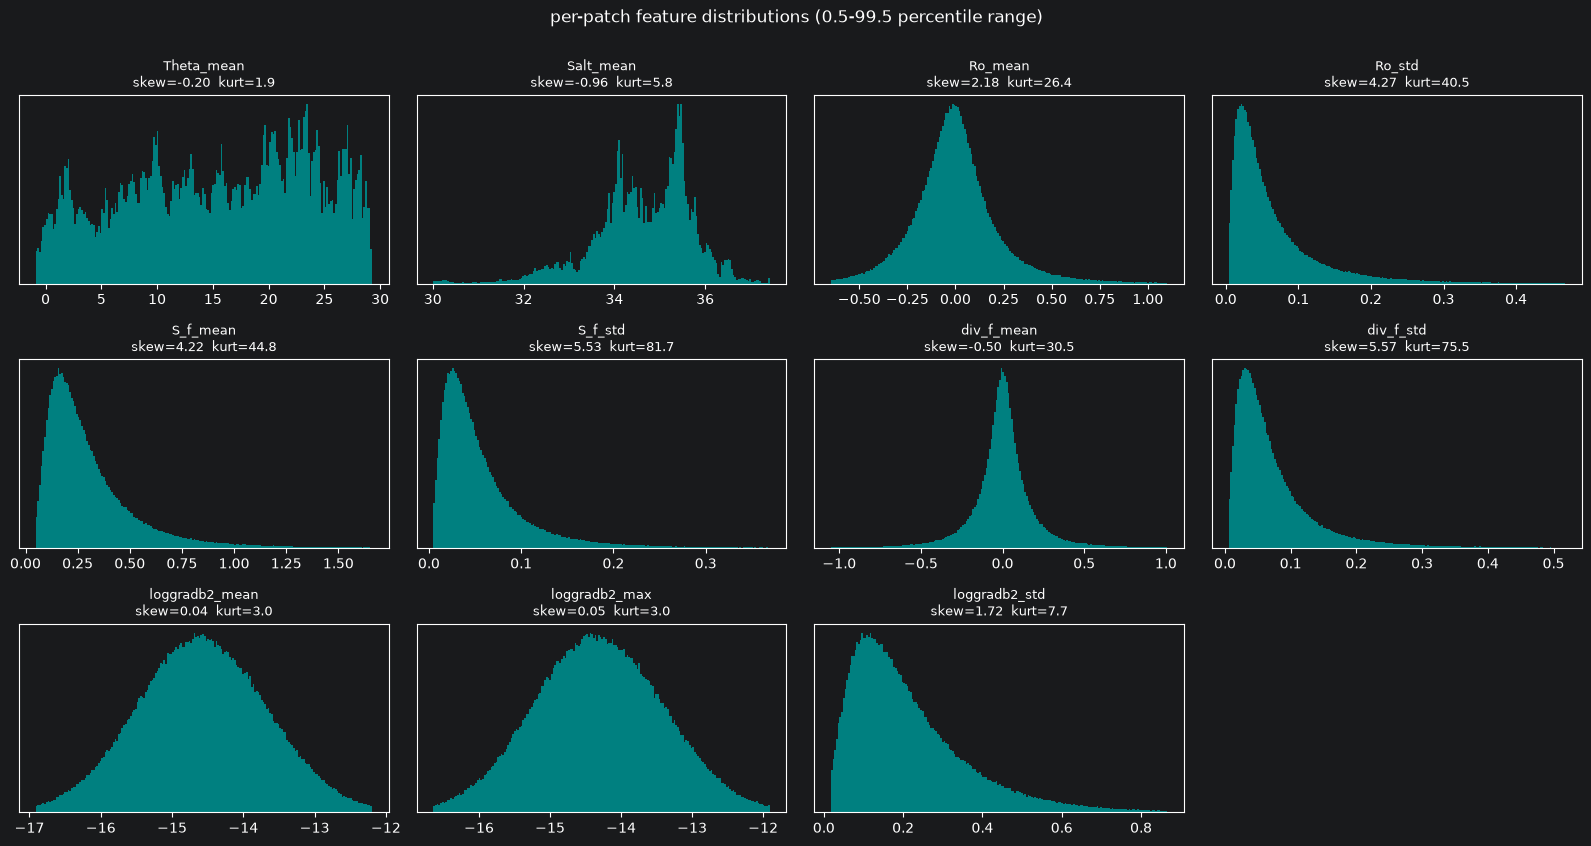

,mean,std,min,max
Theta_mean,15.4578,8.3917,-1.6991,30.7590
Salt_mean,34.6283,1.1536,28.2491,38.9286
Ro_mean,0.0061,0.2620,-3.0786,5.9338
Ro_std,0.0695,0.0783,0.0003,2.1836
S_f_mean,0.3189,0.2675,0.0099,8.5769
S_f_std,0.0600,0.0610,0.0005,2.3224
div_f_mean,-0.0002,0.2584,-7.0951,6.5187
div_f_std,0.0783,0.0846,0.0004,3.2414
loggradb2_mean,-14.5774,0.9162,-18.6895,-10.2499
loggradb2_max,-14.3123,0.9199,-18.5867,-10.0367


,skew,kurtosis,needs_transform
feature,,,
Theta_mean,-0.20,1.90,False
Salt_mean,-0.96,5.75,False
Ro_mean,2.18,26.36,True
Ro_std,4.27,40.48,True
S_f_mean,4.22,44.83,True
S_f_std,5.53,81.66,True
div_f_mean,-0.50,30.46,True
div_f_std,5.57,75.50,True
loggradb2_mean,0.04,3.00,False


In [60]:
feats, near_eq = build_patch_features(dataset, PATCH_SIZE, BLOCK)
# print(f"{len(feats):,} patches | dropping {near_eq.sum():,} within 5 deg of the equator")
# F = feats[~near_eq]

f_cols = 4
f_rows = -(-F.shape[1] // f_cols)
fig, axes = plt.subplots(f_rows, f_cols, figsize=(4 * f_cols, 2.8 * f_rows))
moments = []
for a, col in zip(axes.ravel(), F.columns):
    v = F[col].to_numpy()
    v = v[np.isfinite(v)]
    lo, hi = np.percentile(v, [0.5, 99.5])
    a.hist(v, bins=200, range=(lo, hi), density=True, color="teal")
    z = (v - v.mean()) / (v.std() + 1e-30)
    sk, ku = float((z ** 3).mean()), float((z ** 4).mean())
    moments.append({"feature": col, "skew": sk, "kurtosis": ku,
                    "needs_transform": abs(sk) > 2 or ku > 10})
    a.set_title(f"{col}\nskew={sk:.2f}  kurt={ku:.1f}", fontsize=9)
    a.set_yticks([])
for a in axes.ravel()[F.shape[1]:]:
    a.axis("off")
fig.suptitle("per-patch feature distributions (0.5-99.5 percentile range)", y=1.002)
fig.tight_layout(); plt.show()

display(F.describe().T[["mean", "std", "min", "max"]].round(4))
pd.DataFrame(moments).set_index("feature").round(2)

## Quantile transform

The /f ratios are heavy-tailed by construction -- they are ratios.  Euclidean distance
weights by squared magnitude, so for the most extreme patches a single fat-tailed
feature can supply most of their distance, and those patches then set the scale of the
embedding while the bulk gets compressed.

A quantile transform maps each feature's marginal to a normal while leaving the rank
order untouched: the extreme patches are still the extreme patches, they are simply no
longer placed an order of magnitude further out than everything else.  Cluster
structure lives in the dependence between features, not in the marginals, so
standardizing the marginals leaves it intact.

Every patch is kept, including near-equator ones -- row order has to stay aligned with
get_patches for later visualization.  `near_eq` stays as a diagnostic: the |f| floor
compresses those patches toward zero Ro rather than blowing them up, so they can form
a spurious "quiet" group.  Check it against any cluster that looks suspicious.

In [61]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution="normal", subsample=500_000, random_state=SEED)
feats_q = pd.DataFrame(qt.fit_transform(feats), columns=feats.columns)


def moments(v):
    """(skew, kurtosis) of the finite values."""
    v = v[np.isfinite(v)]
    z = (v - v.mean()) / (v.std() + 1e-30)
    return float((z ** 3).mean()), float((z ** 4).mean())


print(f"{len(feats_q):,} patches x {feats_q.shape[1]} features | "
      f"{near_eq.sum():,} flagged near-equator (kept)")

524,288 patches x 11 features | 12,000 flagged near-equator (kept)


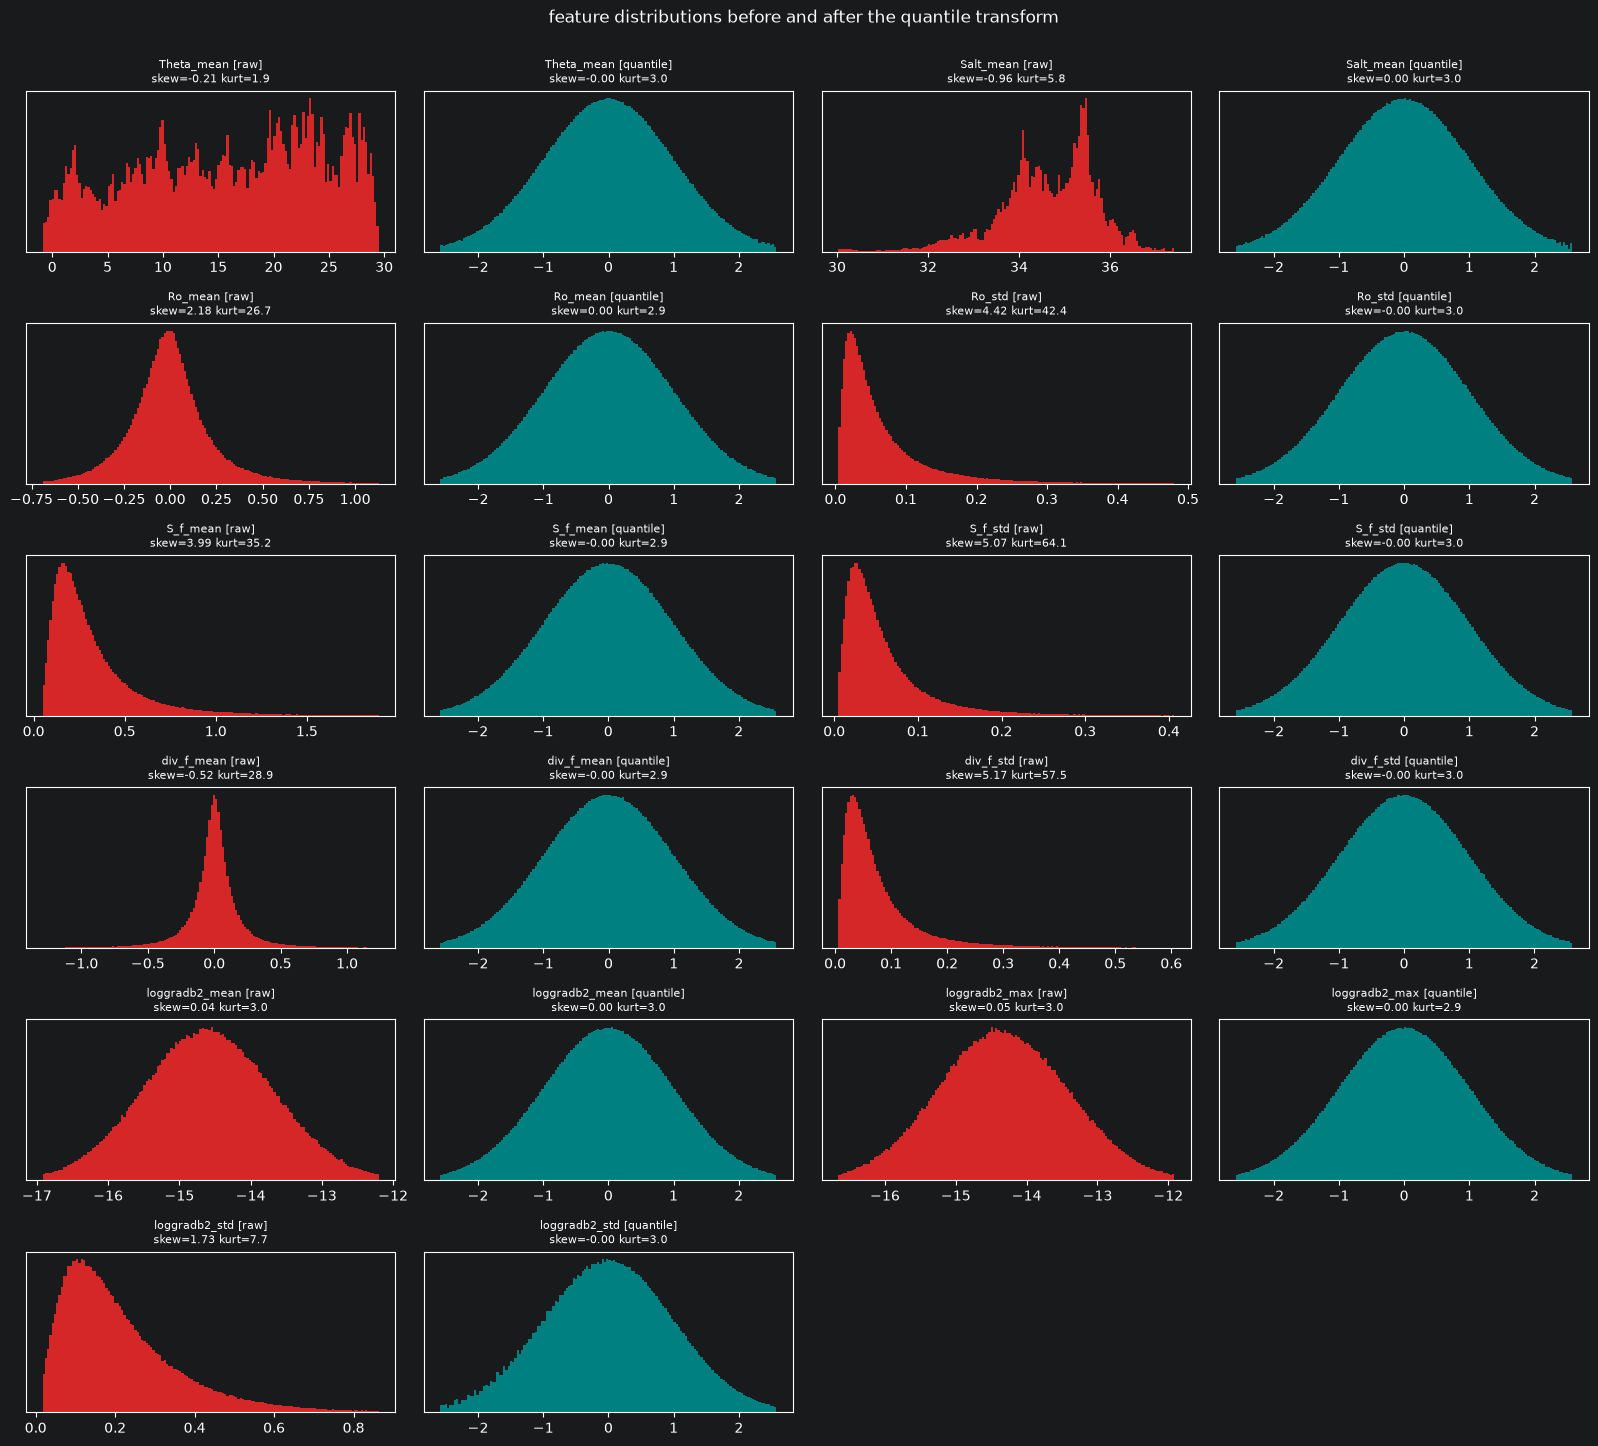

,skew_raw,kurt_raw,skew_q,kurt_q
feature,,,,
Theta_mean,-0.21,1.89,-0.0,2.97
Salt_mean,-0.96,5.77,0.0,2.98
Ro_mean,2.18,26.73,0.0,2.95
Ro_std,4.42,42.36,-0.0,2.96
S_f_mean,3.99,35.23,-0.0,2.95
S_f_std,5.07,64.06,-0.0,2.96
div_f_mean,-0.52,28.95,-0.0,2.94
div_f_std,5.17,57.49,-0.0,2.95
loggradb2_mean,0.04,3.00,0.0,2.95


In [62]:
PAIRS = 2                                  # features per row, each shown raw then transformed
q_rows = -(-feats.shape[1] // PAIRS)
fig, axes = plt.subplots(q_rows, 2 * PAIRS, figsize=(4 * 2 * PAIRS, 2.4 * q_rows), squeeze=False)
rows = []
for i, col in enumerate(feats.columns):
    r, c = divmod(i, PAIRS)
    for j, (src, tag) in enumerate(((feats[col], "raw"), (feats_q[col], "quantile"))):
        a = axes[r][2 * c + j]
        v = src.to_numpy()
        v = v[np.isfinite(v)]
        lo, hi = np.percentile(v, [0.5, 99.5])
        a.hist(v, bins=150, range=(lo, hi), density=True,
               color="tab:red" if tag == "raw" else "teal")
        sk, ku = moments(v)
        a.set_title(f"{col} [{tag}]\nskew={sk:.2f} kurt={ku:.1f}", fontsize=8)
        a.set_yticks([])
        if tag == "raw":
            rows.append({"feature": col, "skew_raw": sk, "kurt_raw": ku})
        else:
            rows[-1].update(skew_q=sk, kurt_q=ku)
for a in axes.ravel()[2 * feats.shape[1]:]:
    a.axis("off")
fig.suptitle("feature distributions before and after the quantile transform", y=1.001)
fig.tight_layout(); plt.show()

shape = pd.DataFrame(rows).set_index("feature")
shape.round(2)

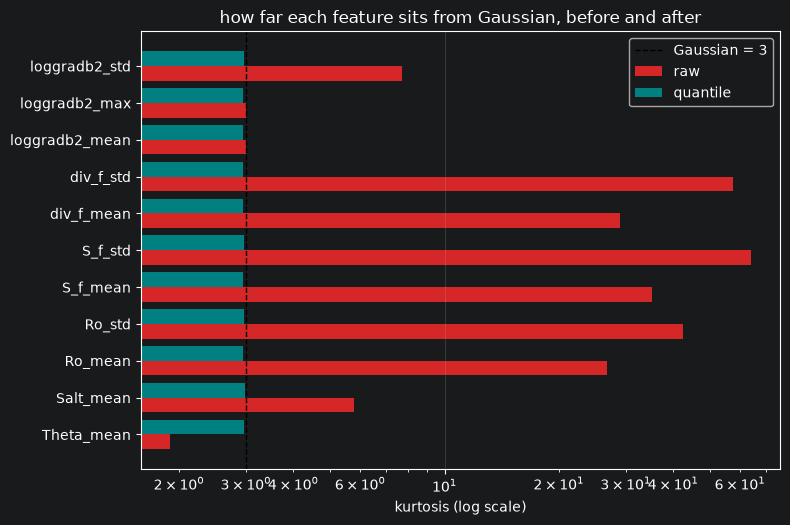

rank order preserved for every feature: True


In [63]:
fig, ax = plt.subplots(figsize=(8, 0.35 * len(shape) + 1.5))
y = np.arange(len(shape))
ax.barh(y - 0.2, shape["kurt_raw"], 0.4, color="tab:red", label="raw")
ax.barh(y + 0.2, shape["kurt_q"], 0.4, color="teal", label="quantile")
ax.axvline(3, color="k", ls="--", lw=1, label="Gaussian = 3")
ax.set_yticks(y); ax.set_yticklabels(shape.index)
ax.set_xscale("log"); ax.set_xlabel("kurtosis (log scale)")
ax.set_title("how far each feature sits from Gaussian, before and after")
ax.legend(); ax.grid(alpha=0.3, axis="x")
fig.tight_layout(); plt.show()

# the transform must not reorder anything -- the extremes stay the extremes
same_order = all(feats[c].rank().corr(feats_q[c].rank(), method="spearman") > 0.999
                 for c in feats.columns)
print(f"rank order preserved for every feature: {same_order}")